In [1]:
# Setup
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import matplotlib.pyplot as plt

from src.visualization import style as st
from src.visualization import charts
from src.visualization.charts import save_figure
from src.storage.sqlite_storage import SQLiteStorage
from src.analysis import transformations as tx

st.apply_theme()

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Carga de datos

from src.analysis import transformations as tx

proc = Path("../data/processed")

# Cargar IPC desde parquet
df_ipc  = pd.read_parquet(proc / "ipc_enriquecido.parquet")
df_wide = pd.read_parquet(proc / "panel_mensual.parquet")

# USD/CLP: la serie del BCCh trae días calendario (con NaN en fines de
# semana y feriados). Filtramos a días con observación antes de las
# columnas derivadas para que el rolling 30d funcione. La capa de análisis
# también lo hace; mantenemos el filtro acá para que el notebook sea
# auto-contenido y reproducible aunque se ejecute aislado.

df_usd = pd.read_parquet(proc / "usd_enriquecido.parquet")
df_usd = (df_usd
          .sort_values("fecha")
          .dropna(subset=["valor"])      # solo días con tipo de cambio observado
          .reset_index(drop=True))

df_usd["ret_1d"]  = tx.pct_change(df_usd, periods=1)
df_usd["ma_30d"]  = tx.rolling_mean(df_usd, window=30)
df_usd["vol_30d"] = tx.rolling_std(df_usd, window=30, value_col="ret_1d")

print("USD/CLP después del filtro:")
print(f"  filas: {len(df_usd)}")
print(df_usd[["valor", "ret_1d", "ma_30d", "vol_30d"]].isna().sum())
print(df_usd[["fecha", "valor", "ma_30d", "vol_30d"]].tail(5).to_string(index=False))
# TPM desde SQLite
storage = SQLiteStorage("../data/bcch.db")
df_tpm = storage.load_series("tpm")
df_tpm["diff_pp"] = tx.diff(df_tpm, periods=1)

# Diagnóstico
print(f"IPC:     {df_ipc['fecha'].min().date()} → {df_ipc['fecha'].max().date()}  ({len(df_ipc)} obs)")
print(f"TPM:     {df_tpm['fecha'].min().date()} → {df_tpm['fecha'].max().date()}  ({len(df_tpm)} obs)")
print(f"USD/CLP: {df_usd['fecha'].min().date()} → {df_usd['fecha'].max().date()}  ({len(df_usd)} obs)")
print()
print("USD/CLP columnas y conteo de NaN:")
print(df_usd[["valor", "ret_1d", "ma_30d", "vol_30d"]].isna().sum())
print()
print("USD/CLP últimas filas:")
print(df_usd[["fecha", "valor", "ma_30d", "vol_30d"]].tail(5).to_string(index=False))

USD/CLP después del filtro:
  filas: 4096
valor       0
ret_1d      1
ma_30d     29
vol_30d    30
dtype: int64
     fecha  valor     ma_30d  vol_30d
2026-05-08 887.71 901.770667 0.888748
2026-05-11 890.89 901.006000 0.892362
2026-05-12 894.25 900.039333 0.872031
2026-05-13 899.91 899.039667 0.869331
2026-05-14 889.19 897.627000 0.889617
IPC:     2009-12-01 → 2026-04-01  (197 obs)
TPM:     2009-12-01 → 2026-05-14  (6009 obs)
USD/CLP: 2009-12-01 → 2026-05-14  (4096 obs)

USD/CLP columnas y conteo de NaN:
valor       0
ret_1d      1
ma_30d     29
vol_30d    30
dtype: int64

USD/CLP últimas filas:
     fecha  valor     ma_30d  vol_30d
2026-05-08 887.71 901.770667 0.888748
2026-05-11 890.89 901.006000 0.892362
2026-05-12 894.25 900.039333 0.872031
2026-05-13 899.91 899.039667 0.869331
2026-05-14 889.19 897.627000 0.889617


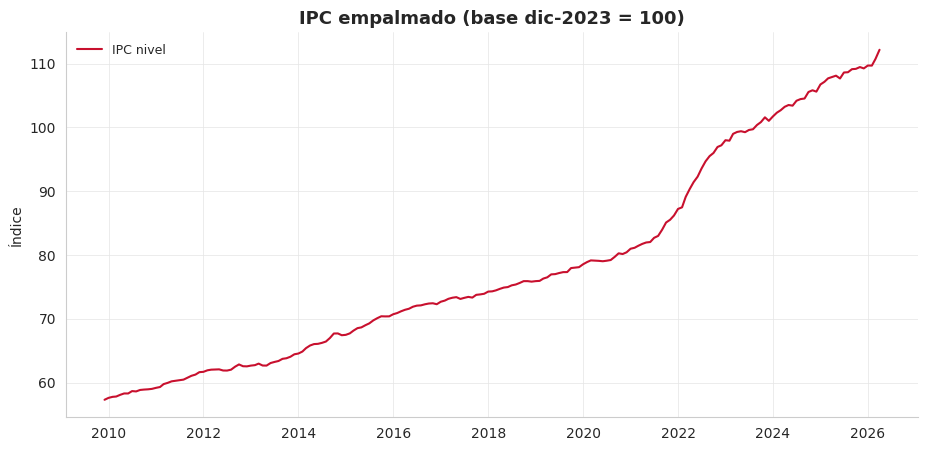

In [3]:
# Graf 1: IPC Nivel
fig, ax = plt.subplots()
charts.plot_ipc_nivel(df_ipc, ax=ax)
save_figure(fig, FIG_DIR / "01_ipc_nivel.png")
plt.show()


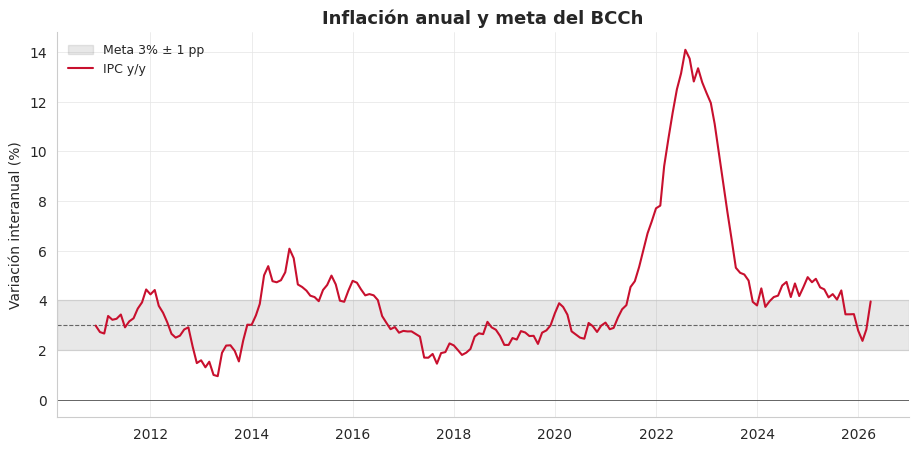

In [4]:
# Grafico 2: IPC y/y + meta inflacion
fig, ax = plt.subplots()
charts.plot_ipc_yoy(df_ipc, ax=ax)
save_figure(fig, FIG_DIR / "02_ipc_yoy_meta.png")
plt.show()

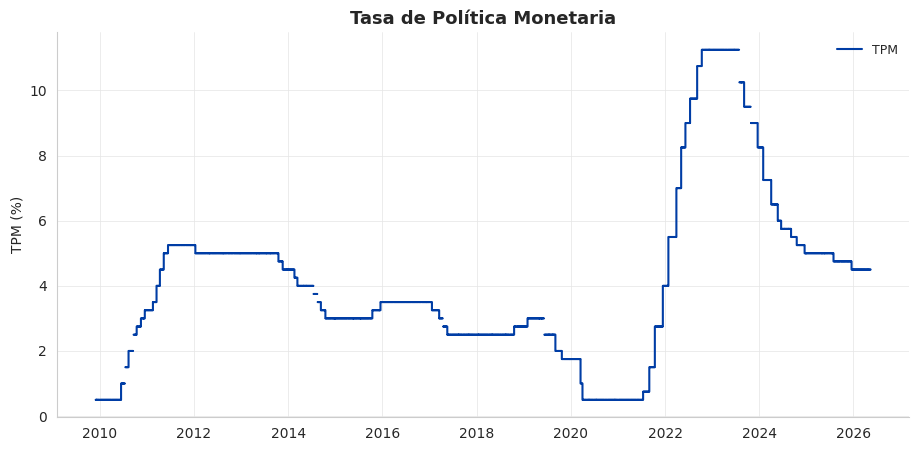

In [5]:
# Grafico 3: TPM

fig, ax = plt.subplots()
charts.plot_tpm(df_tpm, ax=ax)
save_figure(fig, FIG_DIR / "03_tpm.png")
plt.show()

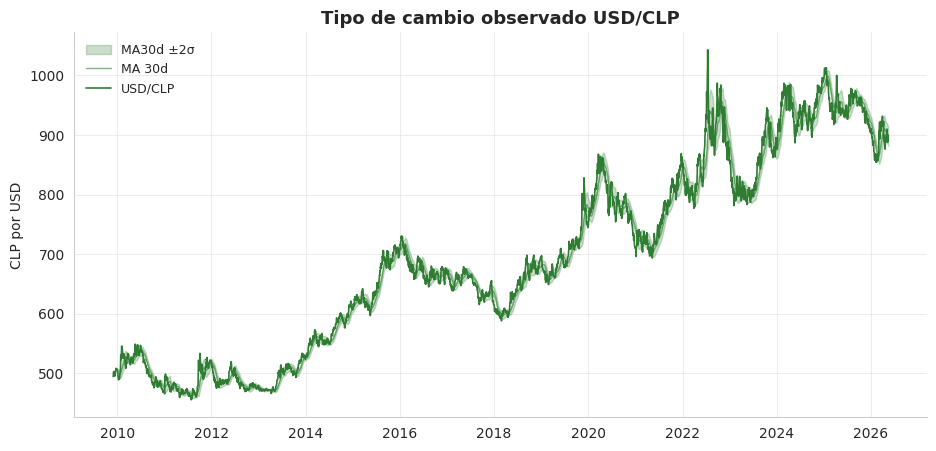

In [6]:
#  Grafico 4: USD/CLP + volatilidad
fig, ax = plt.subplots()
charts.plot_usd_clp(df_usd, ax=ax)
save_figure(fig, FIG_DIR / "04_usd_clp.png")
plt.show()


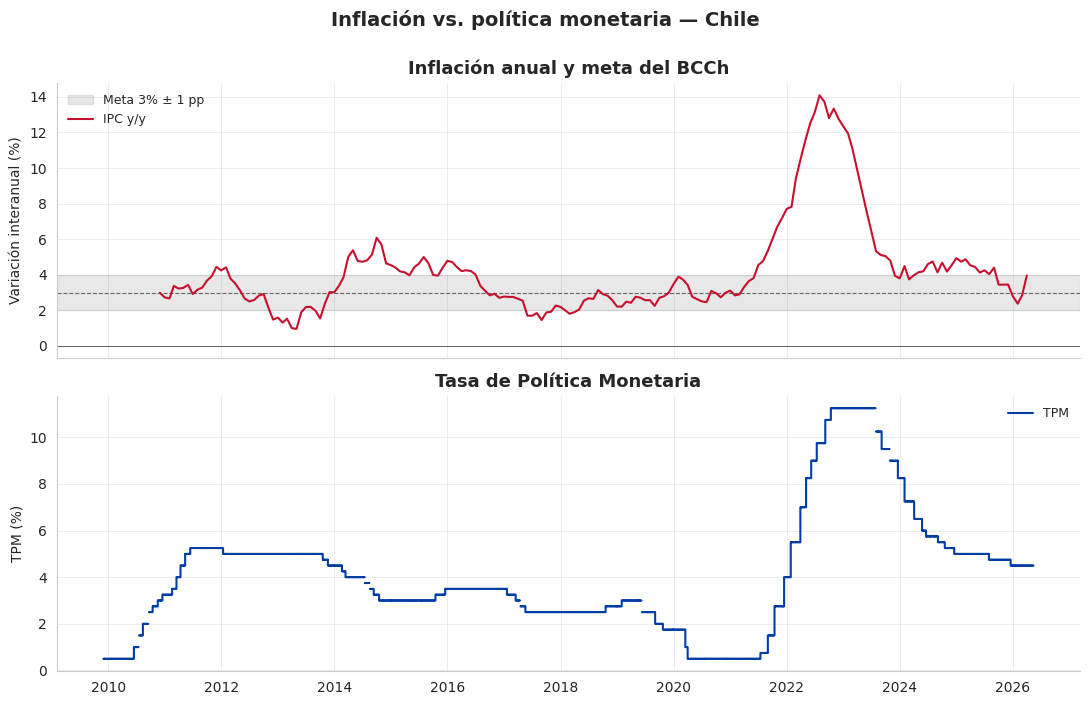

In [7]:
# Grafico 5:  IPC VS TPM

fig = charts.plot_ipc_vs_tpm(df_ipc, df_tpm)
save_figure(fig, FIG_DIR / "05_ipc_vs_tpm.png")
plt.show()

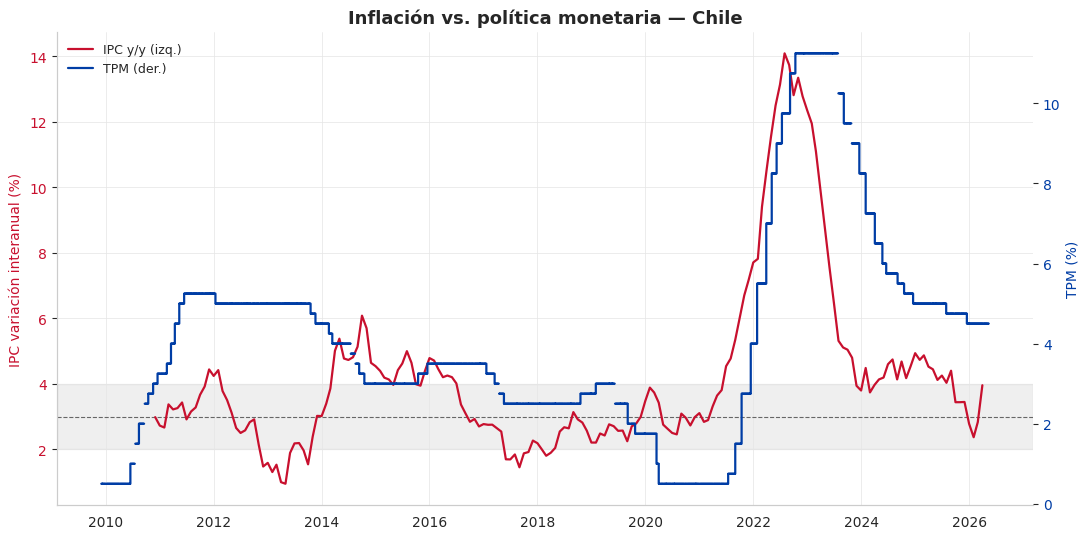

In [8]:
# Grafico 6: IPC vs TPM twinx

fig = charts.plot_ipc_tpm_twinx(df_ipc, df_tpm)
save_figure(fig, FIG_DIR / "06_ipc_tpm_twinx.png")
plt.show()